[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [2]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.0beta34


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

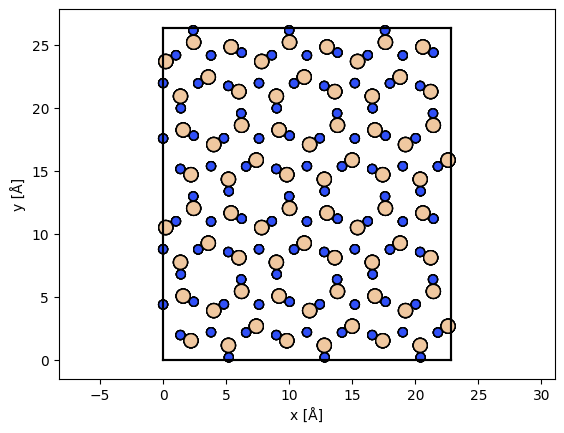

In [3]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.structures.orthogonalize_cell(structure)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

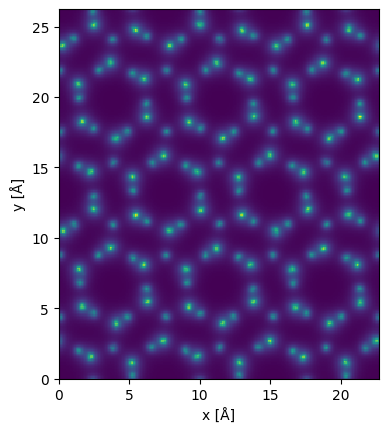

In [4]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

TDS:   0%|          | 0/8 [00:00<?, ?it/s]

Multislice:   0%|          | 0/25 [00:00<?, ?it/s]

Potential:   0%|          | 0/25 [00:00<?, ?it/s]

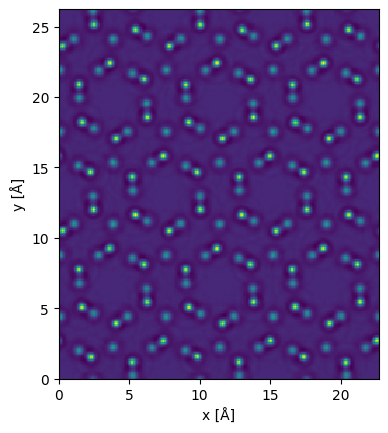

In [5]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
exit_waves.intensity().mean(0).show(cmap='viridis');


---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

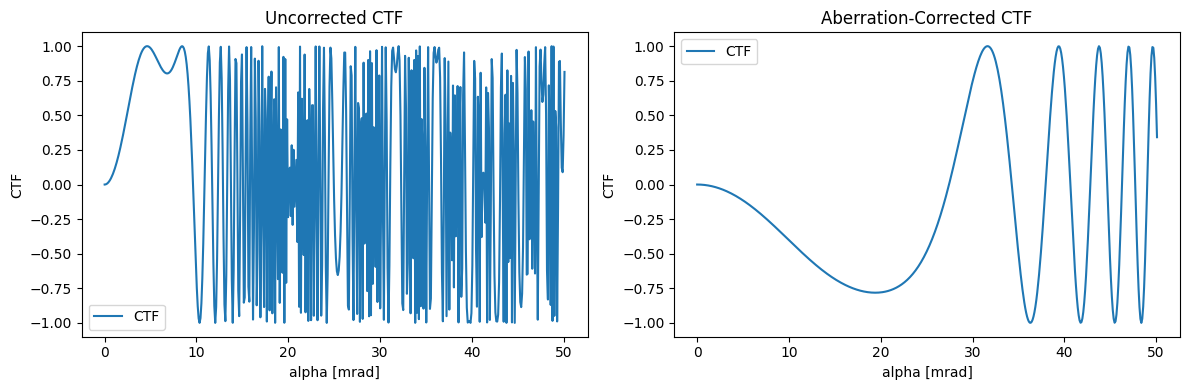

In [6]:
# TASK 3a: Define the UNCORRECTED CTF
# C10 = defocus (Δf) in Å  |  C30 = spherical aberration (Cs) in Å
# For a conventional 300 kV TEM: Cs ≈ 1.3 mm = 1.3e7 Å
parameters_uncorrected = {
    'C10': -600,        # defocus in Å  (negative = underfocus)
    'C30': 1.3e7,       # Cs in Å (1.3 mm)
}
ctf_uncorrected = abtem.CTF(energy=300e3, parameters=parameters_uncorrected)

# TASK 3b: Define the ABERRATION-CORRECTED CTF
# In a Cs-corrected microscope, residual Cs is small and can be negative
parameters_corrected = {
    'C10': 30,          # small defocus in Å
    'C30': -8e4,        # small, negative residual Cs in Å
}
ctf_corrected = abtem.CTF(energy=300e3, parameters=parameters_corrected)

# TASK 3c: Plot both CTFs to compare their spatial frequency transfer
# Hint: use ctf.show() on each CTF object
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ctf_uncorrected.show(ax=axes[0])
axes[0].set_title('Uncorrected CTF')
ctf_corrected.show(ax=axes[1])
axes[1].set_title('Aberration-Corrected CTF')
plt.tight_layout()
plt.show()


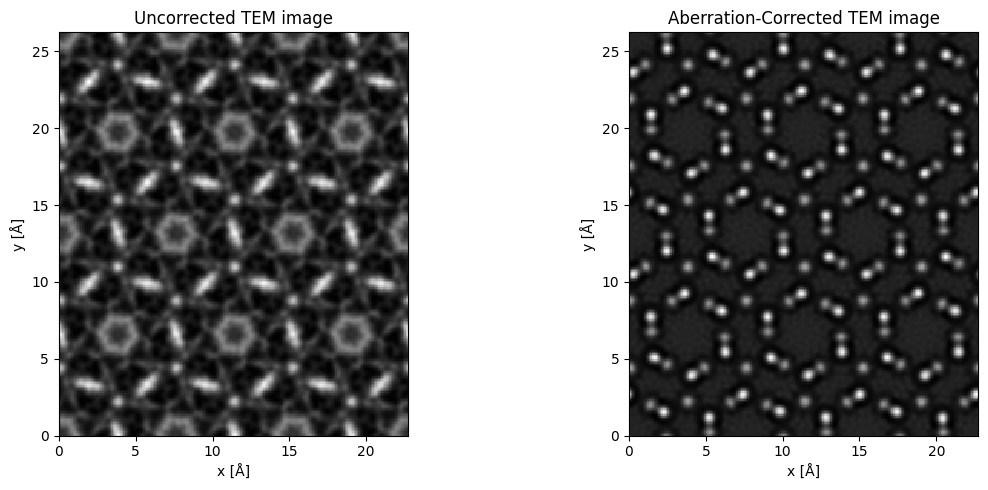

In [7]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

C:\Users\pkwki\AppData\Local\Temp\ipykernel_28224\1480106110.py:9: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  noisy_image = poisson_noise(noiseless_image, dose=dose)


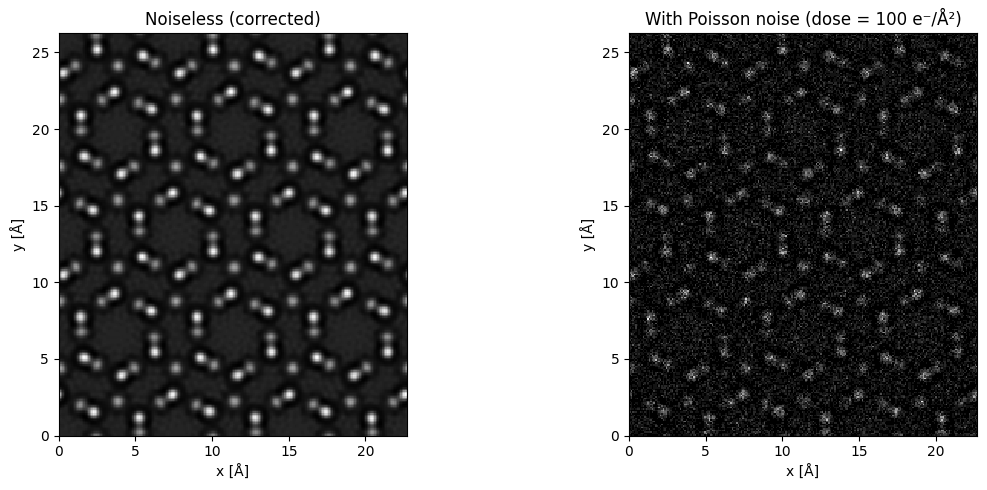

In [8]:
from abtem.noise import poisson_noise

# TASK 4: Apply Poisson noise to the aberration-corrected image
# dose is in electrons per Å²; lower dose → more noise
dose = 100  # e⁻/Å²

# First get the noiseless mean intensity image, then add noise
noiseless_image = image_corrected.intensity().mean(0)
noisy_image = poisson_noise(noiseless_image, dose=dose)

# TASK 4: Plot the noiseless vs noisy images side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap='gray', ax=axes[0])
axes[0].set_title(f'Noiseless (corrected)')

noisy_image.show(cmap='gray', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose} e⁻/Å²)')

plt.tight_layout()
plt.show()


---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**
*The uncorrected CTF shows strong oscillations with multiple zero crossings at relatively low spatial frequencies. This means that certain spatial frequencies are not transferred to the image, leading to loss of information and contrast reversals. In contrast, the aberration-corrected CTF has a much smoother profile with fewer oscillations and extends to higher spatial frequencies. As a result, more high-frequency information is preserved.

Atomic columns appear sharper in the aberration-corrected image because high spatial frequencies, which correspond to fine structural details, are better transferred. Reduced spherical aberration minimizes phase distortions, allowing more accurate imaging of atomic-scale features.*

**2. Defocus and Contrast:**
*Imaging at exactly zero defocus (Δf = 0) is typically avoided in conventional TEM because the CTF at zero defocus does not efficiently transfer low- and intermediate-frequency information. This results in weak phase contrast and poor visibility of atomic features.

The Scherzer defocus is a specific negative defocus value that optimizes contrast by maximizing the transfer of spatial frequencies before the first zero crossing of the CTF. It provides a balance between resolution and contrast, making it the standard imaging condition for conventional HRTEM.*

**3. Simulation vs. Reality:**
*Adding Poisson noise reduces the signal-to-noise ratio, making atomic columns less distinct and more difficult to interpret. At lower electron doses, noise dominates the image, obscuring fine structural details even if they are theoretically present.

In real HRTEM experiments, additional factors can degrade image quality, including sample drift, beam-induced damage, lens instabilities, vibration, imperfect alignment, detector noise, and inelastic scattering. These effects further reduce image clarity beyond what is captured in ideal simulations.*

**4. Multislice Algorithm:**
*The multislice method is necessary for a 5 nm-thick specimen because electron scattering is no longer weak, and multiple scattering events occur as the electron wave propagates through the material. A single projected potential (kinematic approximation) assumes only one interaction and neglects dynamical effects.

In thicker samples, these multiple scattering interactions significantly affect the phase and amplitude of the electron wave. The multislice method accounts for this by propagating the wave through sequential slices of the specimen, providing a more accurate description of electron–matter interaction.*